In [2]:
import tensorflow as tf
from tensorflow.python.profiler import profiler_v2 as profiler
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

Target Phase Matrix:

π 0 π 0 π π π π 0 π
π π 0 π 0 π 0 0 0 0
0 π 0 0 0 π 0 π 0 0
π 0 0 0 0 π π π 0 0
0 0 π 0 0 0 π π π 0
π 0 π 0 0 0 0 0 0 0
0 0 π 0 π π 0 0 π π
0 0 π 0 π 0 0 0 0 π
0 π 0 π 0 0 0 π 0 π
π 0 0 π π π π π π 0
Target Spin Matrix:
[[-1  1 -1  1 -1 -1 -1 -1  1 -1]
 [-1 -1  1 -1  1 -1  1  1  1  1]
 [ 1 -1  1  1  1 -1  1 -1  1  1]
 [-1  1  1  1  1 -1 -1 -1  1  1]
 [ 1  1 -1  1  1  1 -1 -1 -1  1]
 [-1  1 -1  1  1  1  1  1  1  1]
 [ 1  1 -1  1 -1 -1  1  1 -1 -1]
 [ 1  1 -1  1 -1  1  1  1  1 -1]
 [ 1 -1  1 -1  1  1  1 -1  1 -1]
 [-1  1  1 -1 -1 -1 -1 -1 -1  1]]
The shape of the target phase matrix is (10, 10).
The size of the target phase matrix is 100.
Detected Random Phase Matrix:
0 0 0 π 0 0 π π π π
0 0 π 0 0 0 0 π π 0
π 0 0 0 0 0 0 0 0 0
0 π 0 π π π π π 0 π
π 0 0 π π 0 π 0 0 0
0 π 0 0 0 π π π π 0
π π π π π 0 0 π π π
π 0 0 π 0 0 π π π π
0 0 0 π π π 0 0 π π
0 π π 0 0 π 0 0 0 π
Detected Random Spin Matrix:
[[ 1  1  1 -1  1  1 -1 -1 -1 -1]
 [ 1  1 -1  1  1  1  1 -1 -1  1]
 [-1  1 

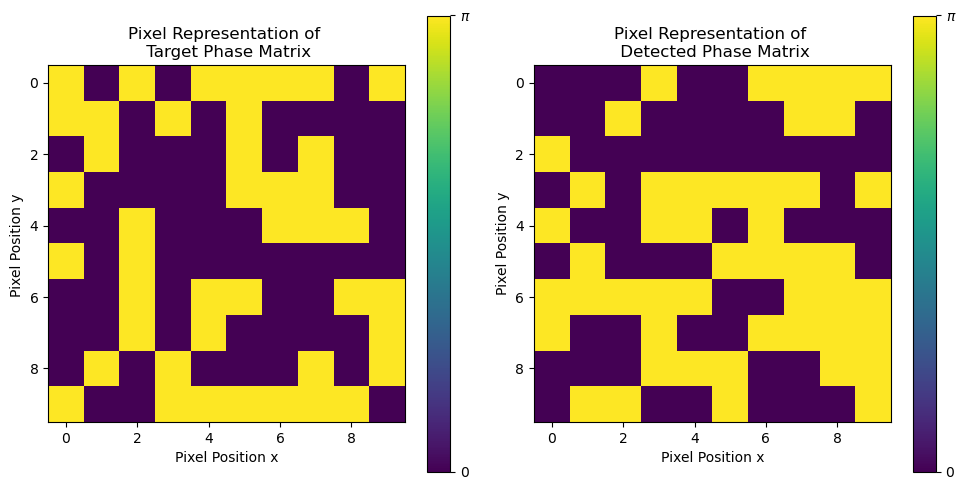

In [3]:
def generate_random_phase_matrix(n):
    """
    Generates a random phase matrix of size nxn.
    """
    # Generate random phases (0 or π)
    phase_matrix = np.random.choice([0, np.pi], size=(n, n))
    return phase_matrix

def binary_phase_to_spin(phase_matrix):
  """Converts a binary phase matrix to a spin variable matrix.
  """
  spin_matrix = np.where(phase_matrix == 0, 1, -1)
  return spin_matrix

def print_phase_matrix_in_pi(phase_matrix):
    """Prints the phase matrix with values displayed as '0' or 'π'."""
    phase_symbols = np.where(phase_matrix == 0, '0', 'π')
    
    # Convert the matrix to a readable string format
    for row in phase_symbols:
        print(' '.join(row))
        
n = 10  # You can adjust this to any value for nxn matrix

target_phase_matrix = generate_random_phase_matrix(n)
target_spin_matrix = binary_phase_to_spin(target_phase_matrix)

detected_phase_matrix = generate_random_phase_matrix(n)
detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)

print("Target Phase Matrix:\n")
print_phase_matrix_in_pi(target_phase_matrix)
print("Target Spin Matrix:")
print(target_spin_matrix)
print(f"The shape of the target phase matrix is {target_phase_matrix.shape}.")
print(f"The size of the target phase matrix is {target_phase_matrix.size}.")

print("Detected Random Phase Matrix:")
print_phase_matrix_in_pi(detected_phase_matrix)
print("Detected Random Spin Matrix:")
print(detected_spin_matrix)
print(f"The shape of the random spin matrix is {detected_spin_matrix.shape}.")
print(f"The size of the random spin matrix is {detected_spin_matrix.size}.")

# it determines the the number of pixels or elements in the spatial domain.

# Create the pixel-like image
# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # gridspec_kw={'width_ratios': [1, 1.1]}

# Plot the spin matrix on the left
axes[0].imshow(target_phase_matrix, cmap='viridis')
axes[0].set_title("Pixel Representation of \n Target Phase Matrix")
axes[0].set_xlabel("Pixel Position x")
axes[0].set_ylabel("Pixel Position y ")

# Plot the random phase matrix on the right
cax = axes[1].imshow(detected_phase_matrix, cmap='viridis')
axes[1].set_title("Pixel Representation of \n Detected Phase Matrix")
axes[1].set_xlabel("Pixel Position x")
axes[1].set_ylabel("Pixel Position y")

# Add colorbar for the phase matrix plot
cbar1 = fig.colorbar(cax, ax=axes[0])
cbar2 = fig.colorbar(cax, ax=axes[1])

# Set the colorbar ticks and labels
cbar_ticks = [0, np.pi]
cbar_labels = ['0', '$\pi$']

cbar1.set_ticks(cbar_ticks)
cbar1.set_ticklabels(cbar_labels)

cbar2.set_ticks(cbar_ticks)
cbar2.set_ticklabels(cbar_labels)

# Show the plots
plt.tight_layout()
plt.savefig('Image_JuypyterNotebook/phase_matrices_comparison.png')  # Save as PNG file
plt.show()

def calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points, factor=1):
    # Calculate the Nyquist frequency
    nyquist_frequency = 1 / (2 * pixel_pitch)

    # Determine the maximum frequency based on the factor
    max_frequency = factor * nyquist_frequency

    # Create the spatial frequency grid
    k = np.linspace(-max_frequency, max_frequency, num_points)
    kx, ky = np.meshgrid(k, k)  # Create a grid of kx, ky
    
    # Optionally apply a scaling factor based on the wavelength
    kx *= (2 * np.pi / wavelength)
    ky *= (2 * np.pi / wavelength)

    return kx, ky
    

Computation Time: 0.5474 seconds


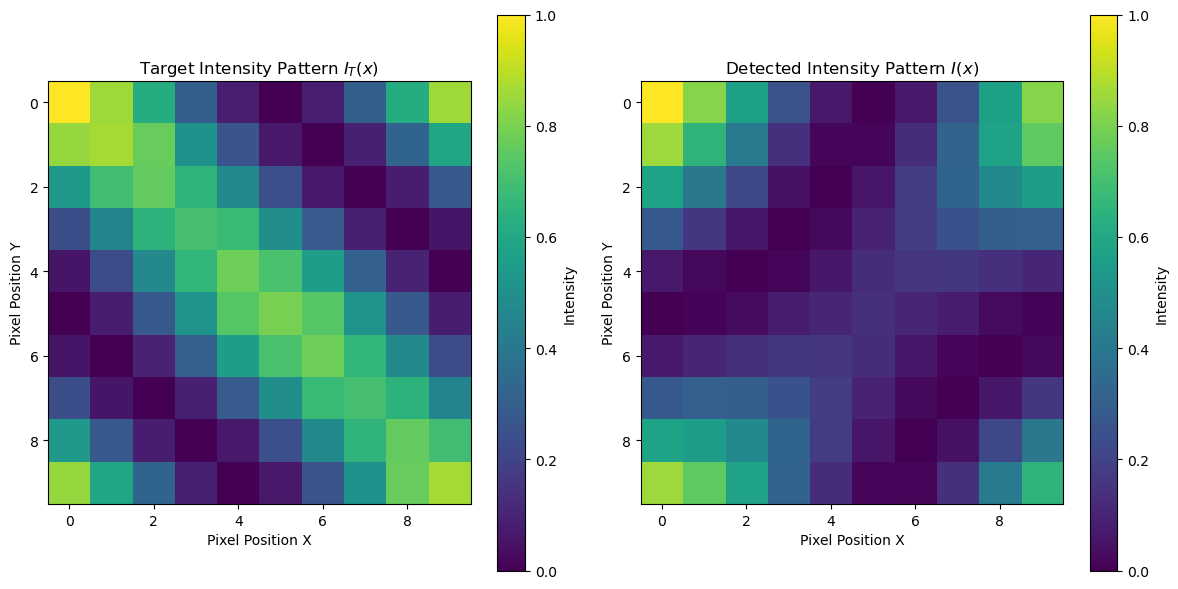

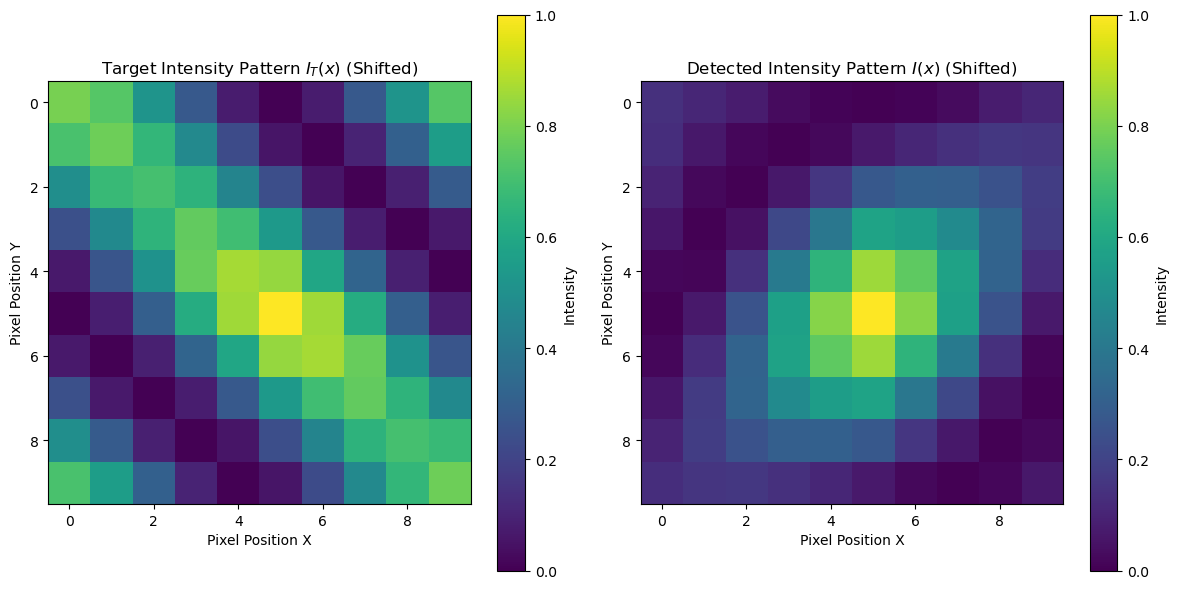

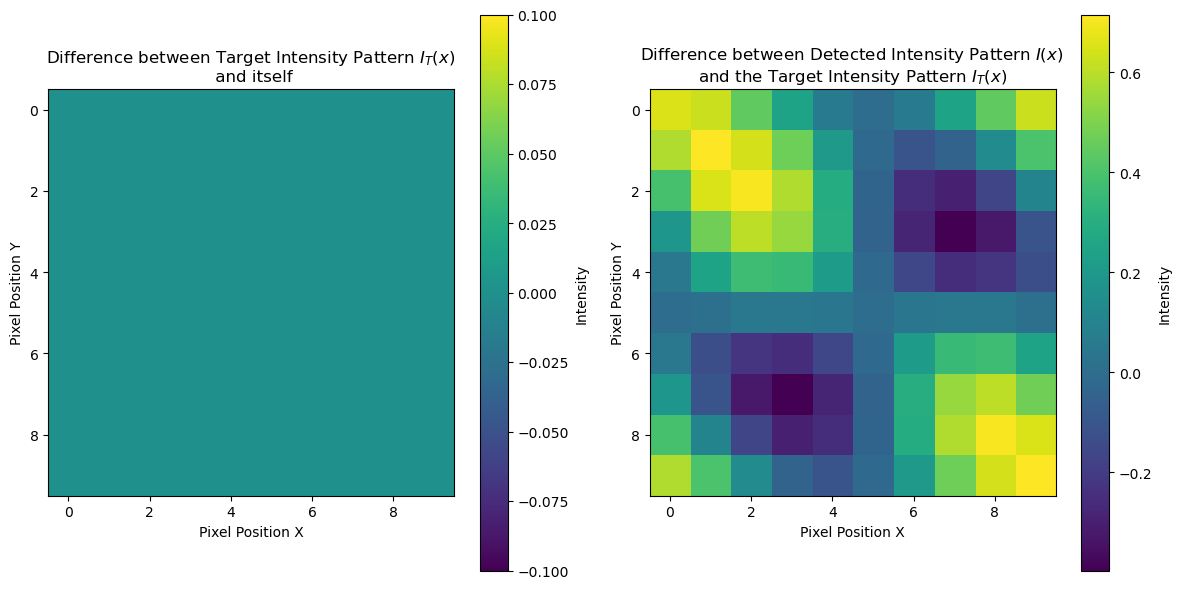

Iteration 0, Energy: 14.394004, Ground State Energy: 14.282792, Cluster Size: 1, Temperature: 9.490500, Ising Energy: 0.000000, Magnetization: 0.060000
Iteration 5, Energy: 6.751279, Ground State Energy: 6.038095, Cluster Size: 15, Temperature: 8.522436, Ising Energy: -4.000000, Magnetization: -0.020000
Iteration 10, Energy: 13.868491, Ground State Energy: 6.038095, Cluster Size: 21, Temperature: 7.270462, Ising Energy: -8.000000, Magnetization: -0.060000
Iteration 15, Energy: 7.954943, Ground State Energy: 6.038095, Cluster Size: 24, Temperature: 6.202407, Ising Energy: 0.000000, Magnetization: -0.080000
Iteration 20, Energy: 13.875724, Ground State Energy: 6.038095, Cluster Size: 26, Temperature: 5.026690, Ising Energy: -4.000000, Magnetization: -0.080000
Iteration 25, Energy: 5.385900, Ground State Energy: 5.385900, Cluster Size: 28, Temperature: 4.288253, Ising Energy: -12.000000, Magnetization: -0.020000
Iteration 30, Energy: 3.102434, Ground State Energy: 3.102434, Cluster Size: 

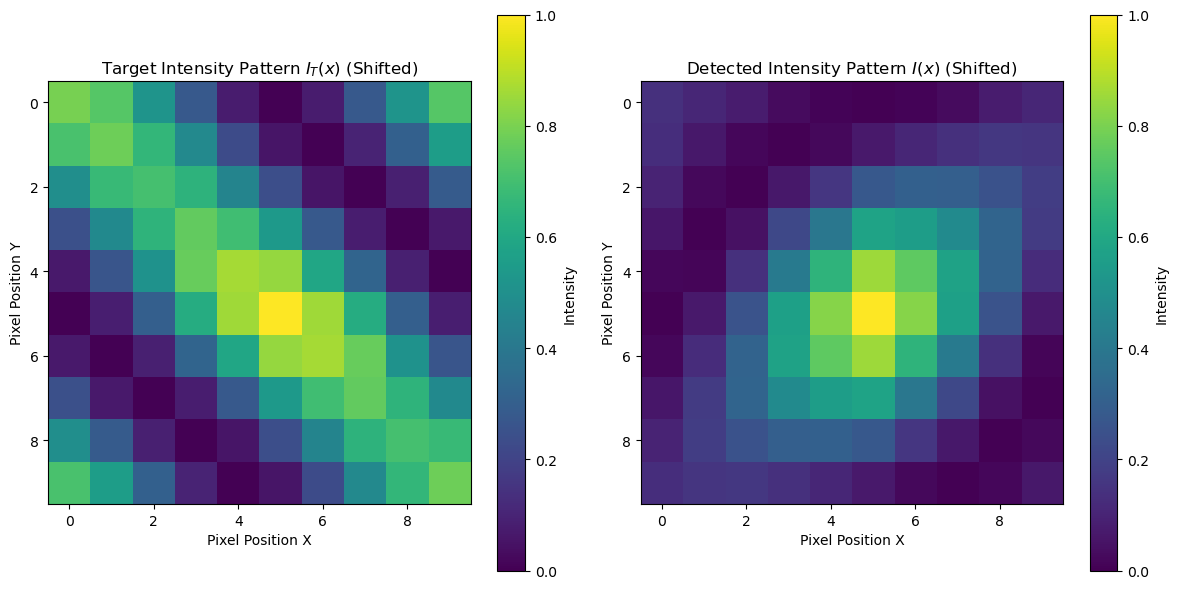

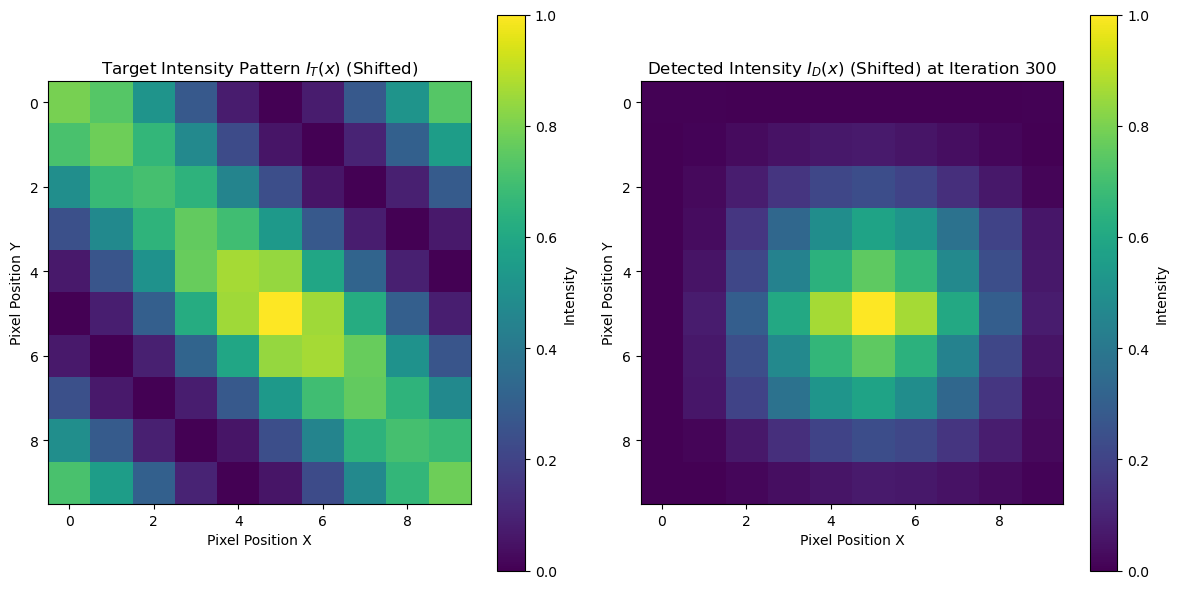

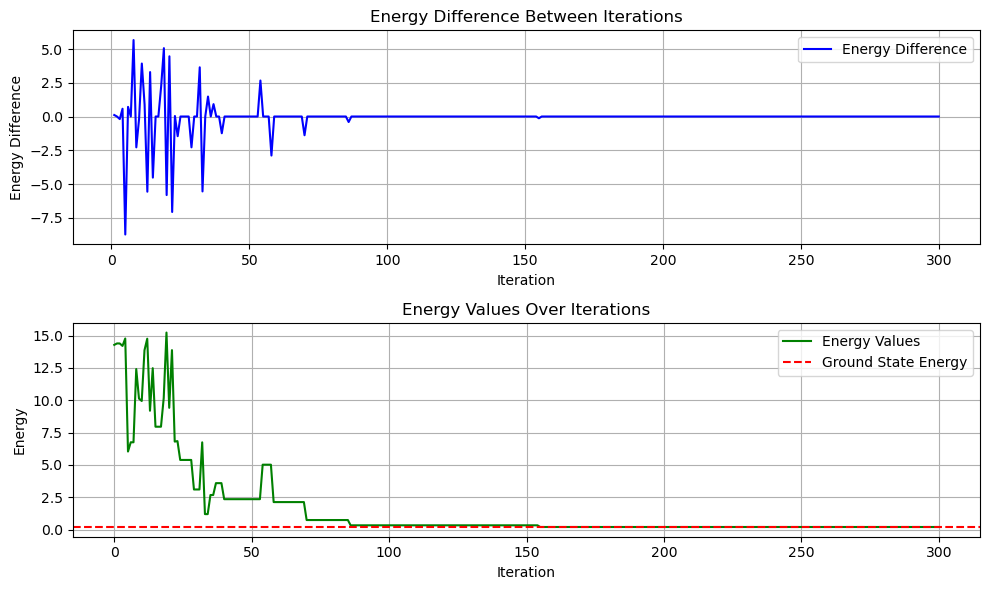

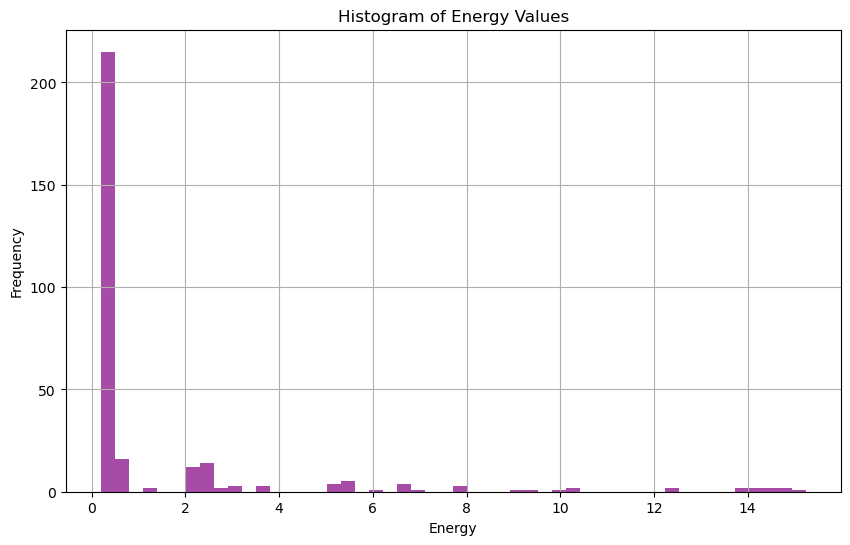

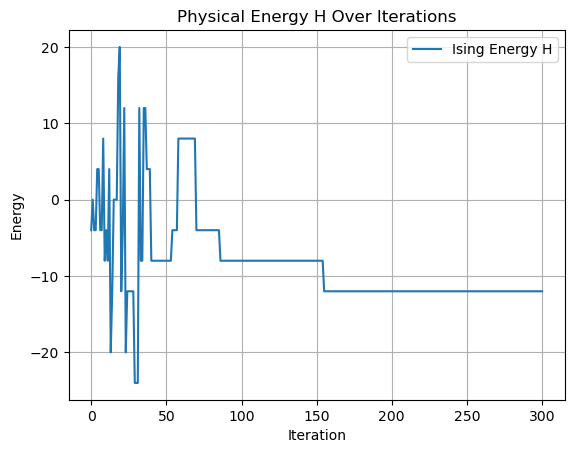

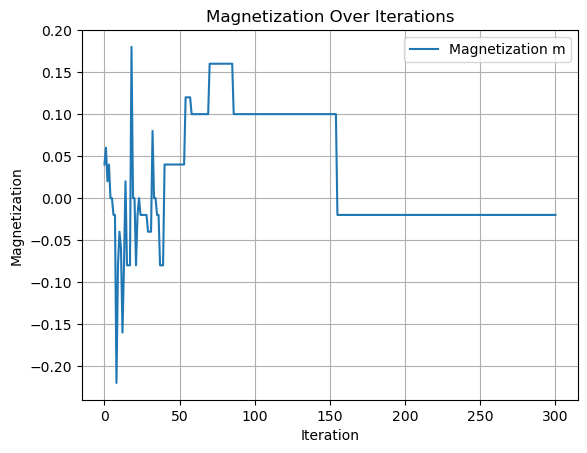

Elapsed Time: 78.58 seconds


In [4]:
xi = 1.0  # Scalar amplitude coefficient
pixel_pitch = 20e-6  # Pixel pitch in meters
W = pixel_pitch / 2  # Half of Pixel pitch
wavelength = 532e-9  # Wavelength in meters
num_points = target_spin_matrix.shape[0]
k = calculate_spatial_frequency_grid(pixel_pitch, wavelength, 100)

def calculate_intensity_fourier(xi, spin_matrix, W, kx, ky, focal_length):

    # Determine n from the input directly
    n = spin_matrix.size
    # Initialize E_k in the Fourier domain (complex field)
    E_k = np.zeros_like(kx, dtype=complex)
    
    # Double summation over j and h
    for j in range(n):
        row_j, col_j = divmod(j, spin_matrix.shape[1])
        k_jx = 2 * W * col_j
        k_jy = 2 * W * row_j
        
        for h in range(n):
            row_h, col_h = divmod(h, spin_matrix.shape[1])
            k_hx = 2 * W * col_h
            k_hy = 2 * W * row_h

            # Calculate delta_W^2(x) using the sinc function for both j and h
            delta_w_square_j = np.sinc(W * (kx - k_jx)) * np.sinc(W * (ky - k_jy))
            delta_w_square_h = np.sinc(W * (kx - k_hx)) * np.sinc(W * (ky - k_hy))

            # Phase factor exp(2iW(h-j)x)
            phase_factor = np.exp(2j * W * ((col_h - col_j) * kx + (row_h - row_j) * ky))

            # Accumulate contributions to the electric field E_k
            E_k += (xi**2 * spin_matrix[row_j, col_j].conjugate() * spin_matrix[row_h, col_h] *
                    delta_w_square_j * delta_w_square_h.conjugate() * phase_factor)
    
    # Inverse Fourier Transform to return to the spatial domain
    E_x = np.fft.ifft2(E_k)
    
    # Intensity I(x) is the square of the magnitude of the electric field
    I_x = np.abs(E_x) ** 2
    
    # Scale the intensity based on the focal length (optional)
    I_x *= (1 / (focal_length ** 2))

    return I_x

# Record the start time
start_time = time.time()

xi = 1.0  # Scalar amplitude coefficient
pixel_pitch = 20e-6  # Pixel pitch in meters
W = pixel_pitch / 2  # Half of Pixel pitch
wavelength = 532e-9  # Wavelength in meters
num_points = target_spin_matrix.shape[0]

# Calculate spatial frequency grid
kx, ky = calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points)

# Calculate intensity pattern
I_x_Target = calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky, focal_length=500e-3)
I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length=500e-3)

# Record the end time
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time

# Print the elapsed time
print(f"Computation Time: {elapsed_time:.4f} seconds")

I_x_Target_normalized = (I_x_Target - np.min(I_x_Target)) / (np.max(I_x_Target) - np.min(I_x_Target))
I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(I_x_Target_normalized, cmap='viridis')
axes[0].set_title("Target Intensity Pattern $I_T(x)$")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(I_x_Detected_normalized, cmap='viridis')
axes[1].set_title("Detected Intensity Pattern $I(x)$")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

# Apply fftshift to center the zero-frequency component
I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(I_x_Target_shifted, cmap='viridis')
axes[0].set_title("Target Intensity Pattern $I_T(x)$ (Shifted)")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(I_x_Detected_shifted, cmap='viridis')
axes[1].set_title("Detected Intensity Pattern $I(x)$ (Shifted)")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('Image_JuypyterNotebook/Intensity.png')  # Save as PNG file

# Apply fftshift to center the zero-frequency component
I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)

intensity_difference_1 = I_x_Target_shifted - I_x_Target_shifted
intensity_difference_2 = I_x_Target_shifted - I_x_Detected_shifted

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(intensity_difference_1, cmap='viridis')
axes[0].set_title("Difference between Target Intensity Pattern $I_T(x)$ \n and itself")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(intensity_difference_2, cmap='viridis')
axes[1].set_title("Difference between Detected Intensity Pattern $I(x)$ \nand the Target Intensity Pattern $I_T(x)$")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.savefig('Image_JuypyterNotebook/Intensity_Difference.png')  # Save as PNG file
plt.show()

# Apply fftshift to center the zero-frequency component
I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(I_x_Target_shifted, cmap='viridis')
axes[0].set_title("Target Intensity Pattern $I_T(x)$ (Shifted)")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(I_x_Detected_shifted, cmap='viridis')
axes[1].set_title("Detected Intensity Pattern $I(x)$ (Shifted)")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('Image_JuypyterNotebook/Intensity.png')  # Save as PNG file

# Apply fftshift to center the zero-frequency component
I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)

intensity_difference_1 = I_x_Target_shifted - I_x_Target_shifted
intensity_difference_2 = I_x_Target_shifted - I_x_Detected_shifted

# # Create a figure with two subplots side by side
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# # Plot the first intensity pattern on the left
# im1 = axes[0].imshow(intensity_difference_1, cmap='viridis')
# axes[0].set_title("Difference between Target Intensity Pattern $I_T(x)$ \n and itself")
# axes[0].set_xlabel("Pixel Position X")
# axes[0].set_ylabel("Pixel Position Y")
# fig.colorbar(im1, ax=axes[0], label="Intensity")

# # Plot the second intensity pattern on the right
# im2 = axes[1].imshow(intensity_difference_2, cmap='viridis')
# axes[1].set_title("Difference between Detected Intensity Pattern $I(x)$ \nand the Target Intensity Pattern $I_T(x)$")
# axes[1].set_xlabel("Pixel Position X")
# axes[1].set_ylabel("Pixel Position Y")
# fig.colorbar(im2, ax=axes[1], label="Intensity")

# # Adjust layout to prevent overlap
# plt.tight_layout()

# # Display the plots
# plt.savefig('Image_JuypyterNotebook/Intensity_Difference.png')  # Save as PNG file
# plt.show()


# Calculate the detected intensity pattern using the Fourier-based function
I_detected_shifted = np.fft.fftshift(calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length = 500*10**(-3)))
# Calculate the target intensity pattern using the Fourier-based function
I_target_shifted = np.fft.fftshift(calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky, focal_length = 500*10**(-3)))

def calculate_energy(I_x_Detected_normalized, I_x_Target_normalized):
    """Calculate energy difference (cost function) between detected and target intensity."""
    return np.sum((I_x_Target_normalized - I_x_Detected_normalized)**2)

def calculate_ising_energy(spin_matrix, J):
    # Assuming J is a uniform matrix and calculating the energy for each neighboring pair
    energy = 0
    for i in range(spin_matrix.shape[0]):
        for j in range(spin_matrix.shape[1]):
            # Assuming periodic boundary conditions for nearest neighbor interaction
            energy -= J[i, j] * spin_matrix[i, j] * (spin_matrix[(i+1) % spin_matrix.shape[0], j] + 
                                                     spin_matrix[i, (j+1) % spin_matrix.shape[1]])
    return energy

def calculate_magnetization(spin_matrix):
    """Calculate the magnetization m of the system."""
    return np.mean(spin_matrix)

def monte_carlo_with_feedback(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations = 300, initial_temperature = 10.0, cooling_rate=0.999):
    n = detected_phase_matrix.shape[0]  # Size of the phase matrix
    detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)
    
    # Initialize J matrix (interaction strength) for Ising model (assumed to be uniform)
    J = np.ones((n, n))  # Assuming uniform interaction between all spins

    # Normalize the target intensity
    I_x_Target_normalized = (I_x_Target_shifted - np.min(I_x_Target_shifted)) / (np.max(I_x_Target_shifted) - np.min(I_x_Target_shifted))
    
    # Compute initial detected intensity and normalize it
    I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
    I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

    # Intensity-based cost function energy
    current_energy = np.sum((I_x_Detected_normalized - I_x_Target_normalized)**2)
    ground_state_energy = current_energy

    # Physical energy H and magnetization m tracking
    ising_energy = calculate_ising_energy(detected_spin_matrix, J)
    magnetization = calculate_magnetization(detected_spin_matrix)
    
    # Track energy values for visualization
    energy_values = [current_energy]
    ising_energy_values = [ising_energy]
    magnetization_values = [magnetization]
    
    temperature = initial_temperature

    for i in range(iterations):
        # Gradually increase cluster size (logarithmic scaling)
        cluster_size = max(1, int(np.log(i+1) / np.log(iterations+1) * (n * n // 2)))
        
        # Randomly flip a gradually increasing cluster of spins
        new_phase_matrix = detected_phase_matrix.copy()
        random_indices = np.random.choice(n * n, cluster_size, replace=False)
        
        for index in random_indices:
            row, col = divmod(index, n)
            new_phase_matrix[row, col] = np.pi - new_phase_matrix[row, col]  # Flip the phase
        
        # Convert the new phase matrix to a spin matrix and calculate new intensity
        new_spin_matrix = binary_phase_to_spin(new_phase_matrix)
        new_intensity = calculate_intensity_fourier(xi, new_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
        new_intensity_normalized = (new_intensity - np.min(new_intensity)) / (np.max(new_intensity) - np.min(new_intensity))
        
        # Calculate new intensity-based energy (cost function)
        new_energy = np.sum((new_intensity_normalized - I_x_Target_normalized)**2)
        energy_diff = new_energy - current_energy

        # Simulated annealing acceptance condition
        if new_energy < current_energy or np.random.rand() < np.exp(-energy_diff / temperature):
            detected_phase_matrix = new_phase_matrix
            current_energy = new_energy
            detected_spin_matrix = new_spin_matrix
        
        # Track physical energy H and magnetization m at every iteration
        ising_energy = calculate_ising_energy(detected_spin_matrix, J)
        magnetization = calculate_magnetization(detected_spin_matrix)

        # Track the ground state energy
        if current_energy < ground_state_energy:
            ground_state_energy = current_energy

        # Append the current values to the tracking lists
        energy_values.append(current_energy)
        ising_energy_values.append(ising_energy)
        magnetization_values.append(magnetization)
        
        # Adaptive cooling: slow down cooling if energy_diff is large
        cooling_factor = cooling_rate if energy_diff < 0.01 else cooling_rate * 0.95
        temperature *= cooling_factor

        # Optionally print progress every few iterations
        if i % 5 == 0:
            print(f"Iteration {i}, Energy: {current_energy:.6f}, Ground State Energy: {ground_state_energy:.6f}, Cluster Size: {cluster_size}, Temperature: {temperature:.6f}, Ising Energy: {ising_energy:.6f}, Magnetization: {magnetization:.6f}")

    # Return all values: phase matrix, ground state energy, energy values, ising energy values, magnetization values, and normalized intensity
    return detected_phase_matrix, ground_state_energy, energy_values, ising_energy_values, magnetization_values, new_intensity_normalized


def visualize_results(I_x_Target_shifted, new_intensity_normalized, energy_values, ground_state_energy, iterations):
    # Apply FFT shift to the final intensity for visualization
    I_x_Final_Detected_shifted = np.fft.fftshift(new_intensity_normalized)
    
    # Create a figure with two subplots side by side for the intensity patterns
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot the target intensity pattern on the left
    im1 = axes[0].imshow(I_x_Target_shifted, cmap='viridis')
    axes[0].set_title("Target Intensity Pattern $I_T(x)$ (Shifted)")
    axes[0].set_xlabel("Pixel Position X")
    axes[0].set_ylabel("Pixel Position Y")
    fig.colorbar(im1, ax=axes[0], label="Intensity")
    
    # Plot the detected intensity pattern on the right (after iterations)
    im2 = axes[1].imshow(I_x_Final_Detected_shifted, cmap='viridis')
    axes[1].set_title(f"Detected Intensity $I_D(x)$ (Shifted) at Iteration {iterations}")
    axes[1].set_xlabel("Pixel Position X")
    axes[1].set_ylabel("Pixel Position Y")
    fig.colorbar(im2, ax=axes[1], label="Intensity")
    
    # Adjust layout and display the plots
    plt.tight_layout()
    plt.savefig('Image_JuypyterNotebook/Intensity_AfterIteraion.png')  # Save as PNG file
    plt.show()

    # Calculate the energy differences between iterations
    energy_diffs = [energy_values[i] - energy_values[i-1] for i in range(1, len(energy_values))]
    
    # Plot energy differences and values over iterations
    plt.figure(figsize=(10, 6))
    
    # Plot 1: Energy differences
    plt.subplot(2, 1, 1)
    plt.plot(range(1, len(energy_diffs) + 1), energy_diffs, label="Energy Difference", color='b')
    plt.xlabel("Iteration")
    plt.ylabel("Energy Difference")
    plt.title("Energy Difference Between Iterations")
    plt.grid(True)
    plt.legend()
    
    # Plot 2: Energy values
    plt.subplot(2, 1, 2)
    plt.plot(range(len(energy_values)), energy_values, label="Energy Values", color='g')
    plt.axhline(y=ground_state_energy, color='r', linestyle='--', label="Ground State Energy")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("Energy Values Over Iterations")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig('Image_JuypyterNotebook/EnergyDifference_EnergyValues.png')  # Save as PNG file
    plt.show()

    # Plot the histogram of energy values
    plt.figure(figsize=(10, 6))
    plt.hist(energy_values, bins=50, color='purple', alpha=0.7)
    plt.xlabel("Energy")
    plt.ylabel("Frequency")
    plt.title("Histogram of Energy Values")
    plt.grid(True)
    plt.savefig('Image_JuypyterNotebook/HistogramEnergy.png')  # Save as PNG file
    plt.show()

    # Visualize Ising Energy H over iterations
    plt.plot(ising_energy_values, label="Ising Energy H")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("Physical Energy H Over Iterations")
    plt.grid(True)
    plt.legend()
    plt.savefig('Image_JuypyterNotebook/PhysicalEnergy.png')  # Save as PNG file
    plt.show()
    
    # Visualize Magnetization over iterations
    plt.plot(magnetization_values, label="Magnetization m")
    plt.xlabel("Iteration")
    plt.ylabel("Magnetization")
    plt.title("Magnetization Over Iterations")
    plt.grid(True)
    plt.legend()
    plt.savefig('Image_JuypyterNotebook/Magnetization.png')  # Save as PNG file
    plt.show()

# Record the start time
start_time_SA = time.time()

# Replace with your GPU setup if applicable
# with tf.device('/GPU:0'):
detected_phase_matrix, ground_state_energy, energy_values, ising_energy_values, magnetization_values, new_intensity_normalized = monte_carlo_with_feedback(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations = 300, initial_temperature = 10.0, cooling_rate=0.999)

visualize_results(I_x_Target_shifted, new_intensity_normalized, energy_values, ground_state_energy, iterations = 300)

# Record the end time
end_time_SA = time.time()

# Calculate elapsed time
elapsed_time_SA = end_time_SA - start_time_SA
print(f"Elapsed Time: {elapsed_time_SA:.2f} seconds")

<function matplotlib.pyplot.show(close=None, block=None)>

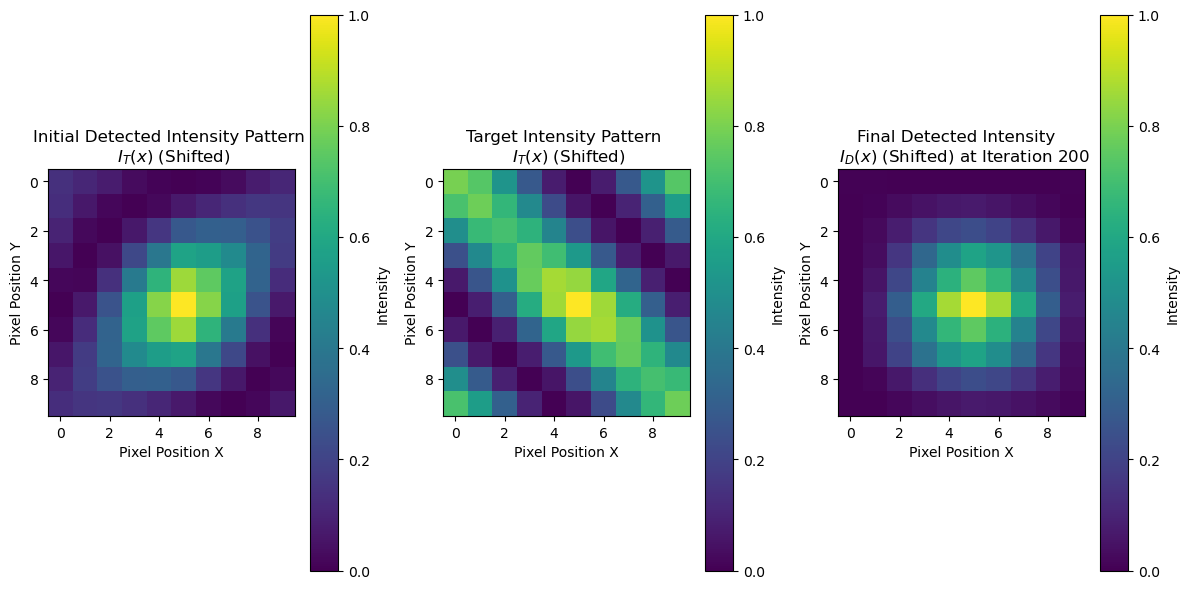

In [5]:
# Assuming you have already calculated 'new_intensity' in the Monte Carlo simulated annealing
I_x_Final_Detected_shifted =  np.fft.fftshift(new_intensity_normalized)  # Final detected intensity after the iterations
# I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)  # Detected intensity before iterations (initial state)

# Create a figure with two subplots side by side for the intensity patterns
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Plot the initial detected intensity pattern on the left
im0 = axes[0].imshow(I_x_Detected_shifted, cmap='viridis')
axes[0].set_title("Initial Detected Intensity Pattern \n $I_T(x)$ (Shifted)")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im0, ax=axes[0], label="Intensity")

# Plot the target intensity pattern on the left
im1 = axes[1].imshow(I_x_Target_shifted, cmap='viridis')
axes[1].set_title("Target Intensity Pattern \n $I_T(x)$ (Shifted)")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[1], label="Intensity")

# Plot the final detected intensity pattern on the right (after iterations)
im2 = axes[2].imshow(I_x_Final_Detected_shifted, cmap='viridis')
axes[2].set_title(f"Final Detected Intensity  \n $I_D(x)$ (Shifted) at Iteration {200}")
axes[2].set_xlabel("Pixel Position X")
axes[2].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[2], label="Intensity")

# Adjust layout and display the plots
plt.tight_layout()
plt.savefig('Image_JuypyterNotebook/IntensityComparisonAfterIteration.png')  # Save as PNG file
plt.show

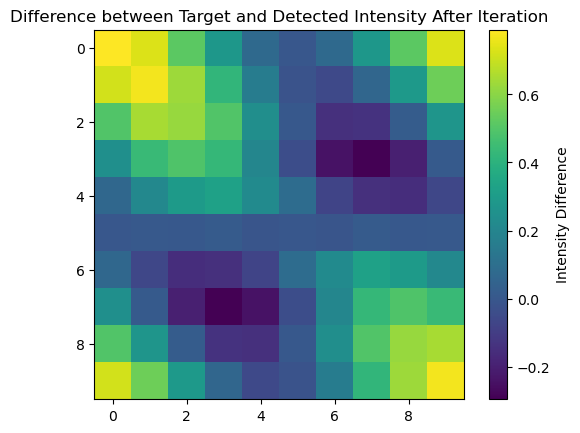

In [6]:
intensity_difference = I_x_Target_shifted - I_x_Final_Detected_shifted
plt.imshow(intensity_difference, cmap='viridis')
plt.colorbar(label="Intensity Difference")
plt.title("Difference between Target and Detected Intensity After Iteration")
plt.savefig('Image_JuypyterNotebook/IntensityDifferenceAfterIteration.png')  # Save as PNG file
plt.show()